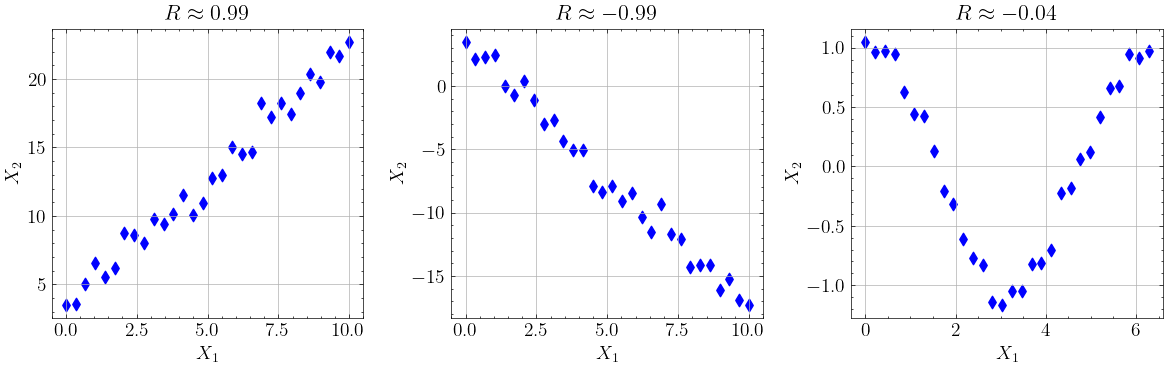

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
plt.style.use('science')
plt.rcParams.update({'font.size': 14})

np.random.seed(42)

n_points = 30
noise = np.random.normal(0, 1, n_points)

x1 = np.linspace(0, 10, n_points)
y1 = 2 * x1 + 3 + noise

x2 = np.linspace(0, 10, n_points)
y2 = -2 * x2 + 3 + noise

x3 = np.linspace(0, 2*np.pi, n_points)
y3 = np.cos(x3) + 0.1*noise

r1 = np.corrcoef(x1, y1)[0, 1]
r2 = np.corrcoef(x2, y2)[0, 1]
r3 = np.corrcoef(x3, y3)[0, 1]


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
datasets = [(x1, y1, r1), (x2, y2, r2), (x3, y3, r3)]
titles = ["Perfekt Positiv", "Perfekt Negativ", "Sinusförmig (Nicht-linear)"]



for i, (ax, (x, y, r)) in enumerate(zip(axes, datasets)):
    # Scatter-Plot zeichnen
    ax.scatter(x, y, color='blue', s=40, marker='d')
    
    # Achsenbeschriftung und Titel (mit gerundetem realen R-Wert)
    ax.set_xlabel(r"$X_1$", fontsize=14)
    ax.set_ylabel(r"$X_2$", fontsize=14)
    ax.set_title(f"$R \\approx {r:.2f}$", fontsize=16, weight="bold")
    ax.grid(True)
    

# Layout optimieren und anzeigen
plt.tight_layout()
plt.show()

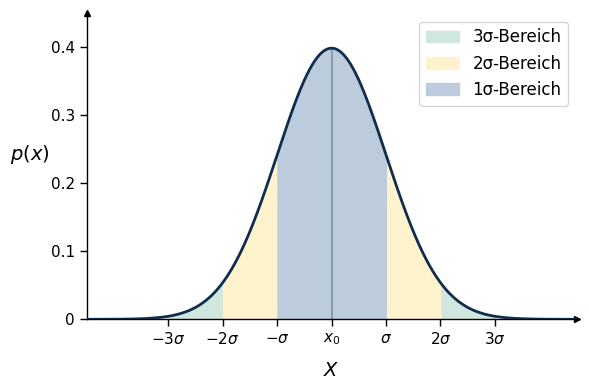

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 0
sigma = 1
x = np.linspace(-4.5, 4.5, 1000)
y = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

color_curve = '#112d4e'  # Dunkelblau für die Hauptlinie
color_1sig = '#bcccdc'   # Angenehmes Blau-Grau für 1 Sigma
color_3sig = '#d1e7dd'   # Leichtes Pastell-Grün für 2 Sigma
color_2sig = '#fff3cd'   # Leichtes Pastell-Gelb für 3 Sigma

ax.fill_between(x, y, where=(x >= -3) & (x <= 3), color=color_3sig, label='3σ-Bereich')
ax.fill_between(x, y, where=(x >= -2) & (x <= 2), color=color_2sig, label='2σ-Bereich')
ax.fill_between(x, y, where=(x >= -1) & (x <= 1), color=color_1sig, label='1σ-Bereich')

ax.plot(x, y, color=color_curve, linewidth=2, zorder=4)
ax.vlines(0, 0, norm.pdf(0, mu, sigma), alpha=0.3, color=color_curve, linestyles='-', linewidth=1.5, zorder=5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#000000')
ax.spines['bottom'].set_color('#000000')
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=5)
ax.plot(-4.5, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=5)

ax.set_xlabel('$X$', fontsize=14, labelpad=10)
ax.set_ylabel('$p(x)$', fontsize=14, labelpad=15, rotation=0, loc='center')

ax.set_xlim(-4.5, 4.5)
ax.set_ylim(0, 0.45)

x_ticks = [-3, -2, -1, 0, 1, 2, 3]
x_labels = [r'$-3\sigma$', r'$-2\sigma$', r'$-\sigma$', r'$x_0$', r'$\sigma$', r'$2\sigma$', r'$3\sigma$']
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=11)

ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4])
ax.set_yticklabels(['0', '0.1', '0.2', '0.3', '0.4'], fontsize=11)
ax.tick_params(axis='both', direction='out', length=5, width=1.0)
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

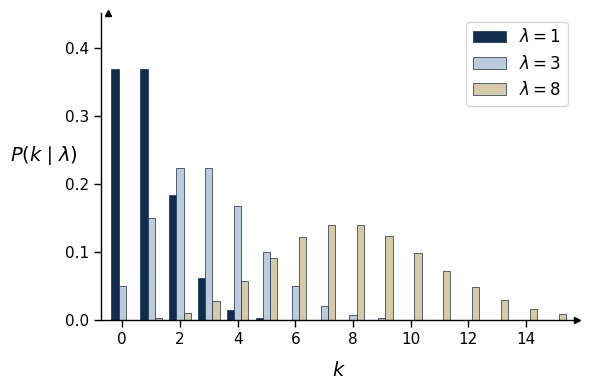

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

x = np.arange(0, 16)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

color_curve = '#112d4e'  # Dunkelblau für die Hauptlinie / größte Lambda
color_1sig = '#bcccdc'   # Angenehmes Blau-Grau
color_2sig = "#d6cba6"   # Leichtes Pastell-Gelb

lambdas = [1, 3, 8]
colors = [color_curve, color_1sig, color_2sig]
labels = [r'$\lambda = 1$', r'$\lambda = 3$', r'$\lambda = 8$']

# Einstellungen für die Balken-Gruppierung
width = 0.25
offsets = [-width, 0, width]

for lam, col, lab, off in zip(lambdas, colors, labels, offsets):
    y = poisson.pmf(x, mu=lam)
    
    # Balken statt Linien/Marker zeichnen
    ax.bar(x + off, y, width=width, color=col, label=lab, 
           edgecolor=color_curve, linewidth=0.5)

# Achsenlinien (Spines) anpassen
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#000000')
ax.spines['bottom'].set_color('#000000')
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# Pfeile an den Achsenenden hinzufügen
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=5)
ax.plot(-0.5, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=5)

# Achsenbeschriftung
ax.set_xlabel(r'$k$', fontsize=14, labelpad=10)
ax.set_ylabel(r'$P(k \mid \lambda)$', fontsize=14, labelpad=15, rotation=0, loc='center')

# Achsenbegrenzungen leicht erweitert, damit die äußeren Balken nicht abgeschnitten werden
ax.set_xlim(-0.75, 15.75)
ax.set_ylim(0, 0.45)

# Ticks und Tick-Labels formatieren
ax.set_xticks(np.arange(0, 16, 2))
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4])
ax.tick_params(axis='both', direction='out', length=5, width=1.0, labelsize=11)

# Legende hinzufügen
ax.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

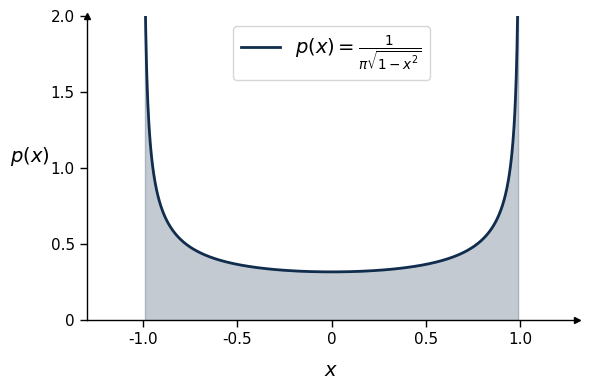

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Definitionsbereich für x definieren (nahe an -1 und 1, um die Singularität zu vermeiden)
xmin_data, xmax_data = -0.99, 0.99
x = np.linspace(xmin_data, xmax_data, 1000)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Farbpalette aus deiner Vorlage
color_curve = '#112d4e'  # Dunkelblau für die Hauptlinie

# Berechnen der Dichtefunktion p(x) mit A = 1
A = 1
y = 1 / (np.pi * np.sqrt(A**2 - x**2))

# Linien und transparente Flächenfüllung im gleichen Design-Stil
ax.plot(x, y, color=color_curve, linewidth=2, label=r'$p(x) = \frac{1}{\pi \sqrt{1 - x^2}}$')
ax.fill_between(x, 0, y, color=color_curve, alpha=0.25)

# Achsenlinien (Spines) anpassen
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#000000')
ax.spines['bottom'].set_color('#000000')
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# Achsenbegrenzungen zuerst setzen, damit die Pfeile korrekt platziert werden
xmin, xmax = -1.3, 1.3
ymin, ymax = 0, 2.0
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Pfeile an den Achsenenden hinzufügen (dynamisch an den linken und unteren Rand angepasst)
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False, markersize=5)
ax.plot(xmin, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False, markersize=5)

# Achsenbeschriftung mit LaTeX-Formatierung
ax.set_xlabel(r'$x$', fontsize=14, labelpad=10)
ax.set_ylabel(r'$p(x)$', fontsize=14, labelpad=15, rotation=0, loc='center')

# Ticks und Tick-Labels sauber setzen
ax.set_xticks([-1.0, -0.5, 0, 0.5, 1.0])
ax.set_xticklabels(['-1.0', '-0.5', '0', '0.5', '1.0'], fontsize=11)
ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])
ax.set_yticklabels(['0', '0.5', '1.0', '1.5', '2.0'], fontsize=11)

ax.tick_params(axis='both', direction='out', length=5, width=1.0)
ax.legend(loc='upper center', fontsize=14)

plt.tight_layout()
plt.show()


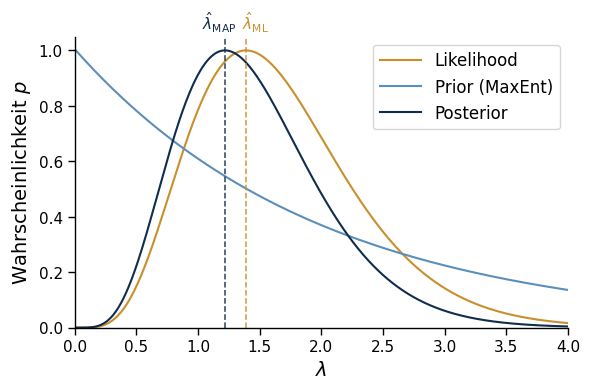

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Beispiel-Daten
# ==========================================================
t = np.array([0.4, 0.8, 0.7, 1.2, 0.5])

N = len(t)
S = np.sum(t)

# Prior: Mittelwert E[λ] = 2
lambda0 = 2.0
alpha = 1 / lambda0

# Schätzer
lambda_ML = N / S
lambda_MAP = N / (S + alpha)

# λ-Achse
lam = np.linspace(0.01, 4, 600)

# ==========================================================
# Likelihood
# ==========================================================
L = lam**N * np.exp(-lam * S)
L /= np.max(L)

# ==========================================================
# Prior (MaxEnt)
# ==========================================================
Prior = alpha * np.exp(-alpha * lam)
Prior /= np.max(Prior)

# ==========================================================
# Posterior
# ==========================================================
Posterior = L * Prior
Posterior /= np.max(Posterior)

# ==========================================================
# Farben
# ==========================================================
color_posterior = "#112d4e"   # Dunkelblau
color_prior = "#5b8fb9"       # Mittelblau
color_likelihood = "#c98f2d"  # Kräftiges Ocker (gut sichtbar)

# ==========================================================
# Plot
# ==========================================================
fig, ax = plt.subplots(figsize=(6, 4))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Likelihood
ax.plot(
    lam,
    L,
    lw=1.5,
    color=color_likelihood,
    label="Likelihood"
)

# Prior
ax.plot(
    lam,
    Prior,
    lw=1.5,
    color=color_prior,
    label="Prior (MaxEnt)"
)

# Posterior
ax.plot(
    lam,
    Posterior,
    lw=1.5,
    color=color_posterior,
    label="Posterior"
)

# ==========================================================
# ML- und MAP-Linien
# ==========================================================
ax.axvline(
    lambda_ML,
    color=color_likelihood,
    linestyle="--",
    linewidth=1.1,
    alpha=0.9
)

ax.axvline(
    lambda_MAP,
    color=color_posterior,
    linestyle="--",
    linewidth=1.1,
    alpha=0.9
)

# Beschriftungen der Schätzer
ax.text(
    lambda_ML + 0.08,
    1.06,
    r'$\hat{\lambda}_{\mathrm{ML}}$',
    color=color_likelihood,
    fontsize=11,
    ha='center',
    va='bottom'
)

ax.text(
    lambda_MAP -0.05,
    1.06,
    r'$\hat{\lambda}_{\mathrm{MAP}}$',
    color=color_posterior,
    fontsize=11,
    ha='center',
    va='bottom'
)
# ==========================================================
# Achsenformatierung
# ==========================================================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#000000')
ax.spines['bottom'].set_color('#000000')

ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# ==========================================================
# Achsenbeschriftung
# ==========================================================
ax.set_xlabel(r'$\lambda$', fontsize=14)
ax.set_ylabel(r"Wahrscheinlichkeit $p$", fontsize=14)

ax.set_xlim(0, 4)
ax.set_ylim(0, 1.05)

ax.tick_params(
    direction='out',
    length=5,
    width=1,
    labelsize=11
)

# Legende
ax.legend(
    frameon=True,
    fontsize=12,
    loc="upper right",
    handlelength=2.5
)

plt.tight_layout()
plt.show()

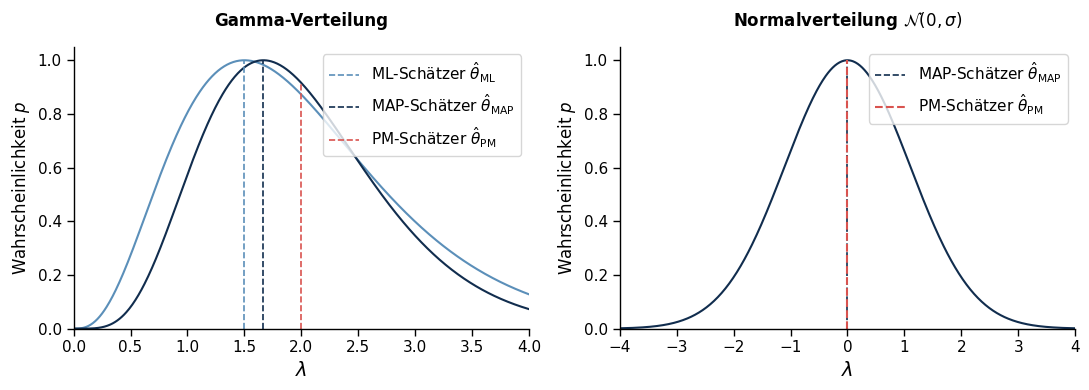

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Daten Linker Plot (Beliebige Gamma-Verteilungen)
# ==========================================================
lam_left = np.linspace(0.01, 4, 600)

# Parameter für die künstliche Gamma-Likelihood (Shape k, Rate beta)
k_like, beta_like = 4.0, 2.0
lambda_ML = (k_like - 1) / beta_like  # Modus (ML) = 1.5

# Parameter für den künstlichen Gamma-Posterior
k_post, beta_post = 6.0, 3.0
lambda_MAP = (k_post - 1) / beta_post  # Modus (MAP) = 1.667
lambda_PM = k_post / beta_post          # Erwartungswert (PM) = 2.0

# Verteilungen berechnen und auf 1 normieren
L = (lam_left ** (k_like - 1)) * np.exp(-beta_like * lam_left)
L /= np.max(L)

Posterior = (lam_left ** (k_post - 1)) * np.exp(-beta_post * lam_left)
max_Post = np.max(Posterior)
Posterior /= max_Post

# Höhenberechnung für die Linien links
y_ML_ax1 = 1.0  
y_MAP_ax1 = 1.0 
# Exakten Wert des normierten Posteriors am Punkt PM berechnen:
y_PM_ax1 = ((lambda_PM ** (k_post - 1)) * np.exp(-beta_post * lambda_PM)) / max_Post

# ==========================================================
# Daten Rechter Plot (Symmetrische Normalverteilung N(0, sigma))
# ==========================================================
lam_right = np.linspace(-4, 4, 600)
sigma = 1.1 

Posterior_norm = np.exp(-0.5 * lam_right**2 / sigma**2)

MAP_right = 0.0
PM_right = 0.0

y_MAP_ax2 = 1.0
y_PM_ax2 = 1.0

# ==========================================================
# Farben & Label-Texte
# ==========================================================
color_posterior = "#112d4e" 
color_likelihood = '#5b8fb9'
color_pm = "#d9534f"

label_ML = r'ML-Schätzer $\hat\theta_{\mathrm{ML}}$'
label_MAP = r'MAP-Schätzer $\hat\theta_{\mathrm{MAP}}$'
label_PM = r'PM-Schätzer $\hat\theta_{\mathrm{PM}}$'

# ==========================================================
# Plot-Erstellung (Nebeneinander)
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor("white")

# Grundformatierung für beide Achsen
for ax in [ax1, ax2]:
    ax.set_facecolor("white")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#000000')
    ax.spines['bottom'].set_color('#000000')
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.set_ylabel(r"Wahrscheinlichkeit $p$", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.tick_params(direction='out', length=5, width=1, labelsize=11)

# ----------------------------------------------------------
# Linker Plot: Gamma-Verteilungen
# ----------------------------------------------------------
ax1.plot(lam_left, L, lw=1.5, color=color_likelihood)
ax1.plot(lam_left, Posterior, lw=1.5, color=color_posterior)
ax1.set_title("Gamma-Verteilung", fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel(r'$\lambda$', fontsize=14)
ax1.set_xlim(0, 4)

# Vertikale Linien bis zur jeweiligen Kurvenhöhe
ax1.plot([lambda_ML, lambda_ML], [0, y_ML_ax1], color=color_likelihood, linestyle="--", linewidth=1.2, label=label_ML)
ax1.plot([lambda_MAP, lambda_MAP], [0, y_MAP_ax1], color=color_posterior, linestyle="--", linewidth=1.2, label=label_MAP)
ax1.plot([lambda_PM, lambda_PM], [0, y_PM_ax1], color=color_pm, linestyle="--", linewidth=1.2, label=label_PM)
ax1.legend(frameon=True, fontsize=11, loc="upper right")

# ----------------------------------------------------------
# Rechter Plot: Normalverteilung N(0, sigma)
# ----------------------------------------------------------
ax2.plot(lam_right, Posterior_norm, lw=1.5, color=color_posterior)
ax2.set_title(r"Normalverteilung $\mathcal{N}(0, \sigma)$", fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel(r'$\lambda$', fontsize=14)
ax2.set_xlim(-4, 4)

ax2.plot([MAP_right, MAP_right], [0, y_MAP_ax2], color=color_posterior, linestyle="--", linewidth=1.2, label=label_MAP)
ax2.plot([PM_right, PM_right], [0, y_PM_ax2], color=color_pm, linestyle="--", linewidth=1.5, label=label_PM)
ax2.legend(frameon=True, fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

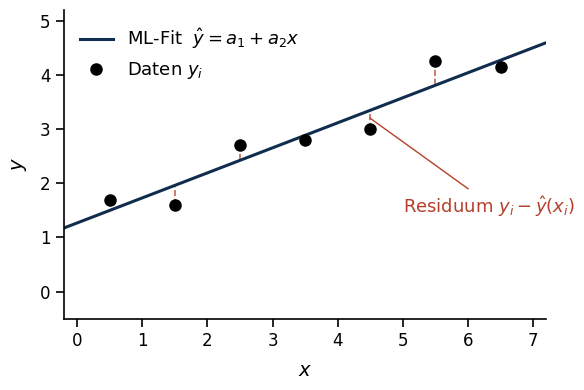

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Datenpunkte (exakt an die Abbildung angepasst)
# ==========================================================
x = np.array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
y = np.array([1.7, 1.6, 2.7, 2.8, 3.0, 4.25, 4.15])

# Berechnug des Maximum-Likelihood-Fits (lineare Regression)
slope, intercept = np.polyfit(x, y, 1)

# Werte für die Regressionsgerade
x_line = np.linspace(-0.2, 7.2, 100)
y_line = intercept + slope * x_line

# Angepasste Werte an den Datenpunkten für die Residuen
y_pred = intercept + slope * x

# ==========================================================
# Farben (Designvorlage)
# ==========================================================
color_fit = "#112d4e"         # Dunkelblau für den ML-Fit
color_data = "#000000"        # Schwarz für die Datenpunkte
color_residual = "#b53f2a"    # Rotbraun für Residuen und Beschriftung

# ==========================================================
# Plot-Erstellung
# ==========================================================
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 1. Vertikale Residuen-Linien (gestrichelt)
ax.vlines(
    x, y, y_pred, 
    colors=color_residual, 
    linestyles="--", 
    linewidth=1.2, 
    alpha=0.8
)

# 2. ML-Fit Regressionsgerade
ax.plot(
    x_line, y_line, 
    color=color_fit, 
    lw=2.2, 
    label=r'ML-Fit  $\hat{y} = a_1 + a_2 x$'
)

# 3. Datenpunkte
ax.plot(
    x, y, 
    color=color_data, 
    marker='o', 
    linestyle='None', 
    markersize=8, 
    label=r'Daten $y_i$'
)

# ==========================================================
# Beschriftungen & Hinweislinie (Residuum)
# ==========================================================
# Schräge Hinweislinie vom Text zum Datenpunkt bei x=4.5
ax.plot([4.5, 6.0], [3.2, 1.9], color=color_residual, lw=1.0)

# Text für das Residuum
ax.text(
    5.0, 1.8, 
    r'Residuum $y_i - \hat{y}(x_i)$', 
    color=color_residual, 
    fontsize=13, 
    ha='left', 
    va='top'
)

# ==========================================================
# Achsenformatierung & Spines
# ==========================================================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#000000')
ax.spines['bottom'].set_color('#000000')
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Achsenbegrenzungen & Labels
ax.set_xlim(-0.2, 7.2)
ax.set_ylim(-0.5, 5.2)
ax.set_xlabel(r'$x$', fontsize=14, labelpad=8)
ax.set_ylabel(r'$y$', fontsize=14, labelpad=8)

# Ticks konfigurieren
ax.set_xticks(range(8))
ax.set_yticks(range(6))
ax.tick_params(direction='out', length=6, width=1.2, labelsize=12)

# Legende (oben links, ohne Rahmen)
ax.legend(frameon=False, fontsize=13, loc="upper left", handlelength=1.8)

plt.tight_layout()
plt.show()

2.56 0.10361306223959729


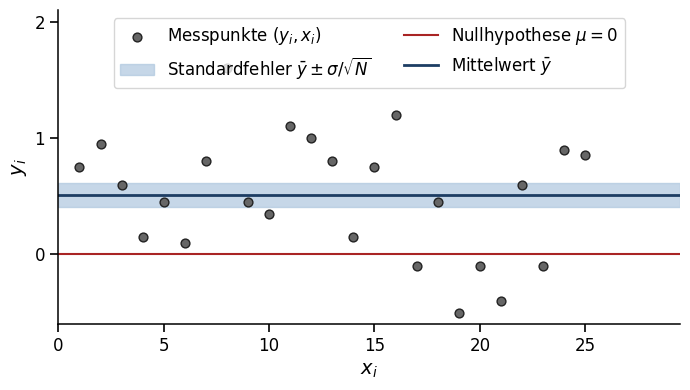

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, 26)
y = np.array([
    0.75, 0.95, 0.60, 0.15, 0.45, 0.10, 0.80, 1.6, 0.45, 0.35,
    1.10, 1.00, 0.80, 0.15, 0.75, 1.20, -0.10, 0.45, -0.50, -0.10,
    -0.40, 0.60, -0.10, 0.90, 0.85
])

mean_y = np.mean(y)
std_y = np.std(y, ddof=1) 
n = len(y)
sem_y = std_y / np.sqrt(n) 
print(mean_y*5, sem_y)

fig, ax = plt.subplots(figsize=(7, 4),)
ax.scatter(x, y, color='#666666', edgecolor='#222222', s=40, zorder=3, label=r'Messpunkte $(y_i, x_i)$')
ax.axhspan(mean_y - sem_y, mean_y + sem_y, color="#aec7df", alpha=0.7, 
           label=r'Standardfehler $\bar{y} \pm \sigma/\sqrt{N}$')
ax.axhline(0, color='#a92424', linewidth=1.5, label=r'Nullhypothese $\mu = 0$')

ax.axhline(mean_y, color='#1d3d63', linewidth=2, label=r'Mittelwert $\bar{y}$')


# 4. Achsen- und Layout-Design (Spines im "Seaborn-Look" reduzieren)
ax.set_xlabel('$x_i$', fontsize=14)
ax.set_ylabel('$y_i$', fontsize=14)

# Achsenbegrenzungen analog zur Vorlage
ax.set_xlim(0, 29.5)
ax.set_ylim(-0.6, 2.1)

ax.set_xticks([0, 5, 10, 15, 20, 25])
ax.set_yticks([0, 1, 2])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.1)
ax.spines['bottom'].set_linewidth(1.1)
ax.tick_params(direction='out', length=6, width=1.2, labelsize=12)
ax.legend(loc='upper center', frameon=True, ncols=2, fontsize=12)

plt.tight_layout()
plt.show()